In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('powerplant_ds.csv')
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
X = df.drop(columns=['PE'])
y = df['PE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)



In [6]:
type(X_train_scaled)

numpy.ndarray

In [7]:
type(y_train)

pandas.core.series.Series

In [8]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [15]:
# ANN Model Definition

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6,1),
        )

    def forward(self, x):
            x = self.model(x)
            return x 

In [16]:
import torch.optim as optim

model = ANN()

# loss, Optimiser
criterion = nn.MSELoss()
optimiser = optim.Adam(model.parameters())

In [ ]:
# Training Model 

train_losses = []
val_losses = []
best_val_loss = float('inf')

epochs = 60

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for xb, yb in train_loader:
        optimiser.zero_grad()
        
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimiser.step()
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()
    
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f'Epoch {epoch+1}/{epochs} => train loss = {epoch_train_loss} and val loss = {epoch_val_loss}')

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_model.pt') # .pt or .pth

Text(0, 0.5, 'Losses')

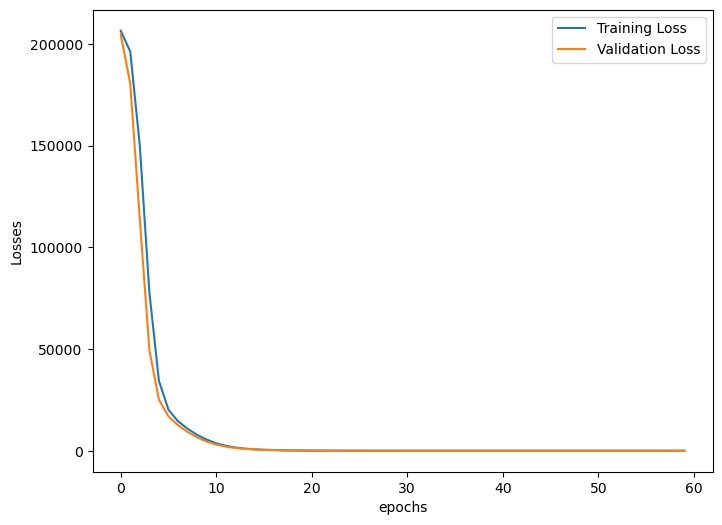

In [18]:
loss_df = pd.DataFrame({
    'train_loss' : train_losses,
    'val_loss' : val_losses
})

plt.figure(figsize=(8,6))
plt.plot(loss_df['train_loss'], label='Training Loss')
plt.plot(loss_df['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('Losses')

In [19]:
model.load_state_dict(torch.load('best_model.pt', weights_only=True))

<All keys matched successfully>